In [1]:
#importing all the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [2]:
# Load the dataset
df = pd.read_csv("global_cancer_patients_2015_2024.csv")

# Show basic info and head of the dataset
df_info = df.info()
df_head = df.head()

df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000.000000
unique,50000,NaN,3,10,NaN,NaN,NaN,NaN,NaN,NaN,8,5,NaN,NaN,NaN
top,PT0049983,NaN,Male,Australia,NaN,NaN,NaN,NaN,NaN,NaN,Colon,Stage II,NaN,NaN,NaN
freq,1,NaN,16796,5092,NaN,NaN,NaN,NaN,NaN,NaN,6376,10124,NaN,NaN,NaN
mean,NaN,54.421540,NaN,NaN,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,NaN,NaN,52467.298239,5.006462,4.951207
std,NaN,20.224451,NaN,NaN,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,NaN,NaN,27363.229379,2.883335,1.199677
min,NaN,20.000000,NaN,NaN,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,5000.050000,0.000000,0.900000
25%,NaN,37.000000,NaN,NaN,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,NaN,NaN,28686.225000,2.500000,4.120000
50%,NaN,54.000000,NaN,NaN,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN,NaN,52474.310000,5.000000,4.950000
75%,NaN,72.000000,NaN,NaN,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,NaN,NaN,76232.720000,7.500000,5.780000


In [3]:
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
print("Unique Values per Column:\n", df.nunique())

Dataset Shape: (50000, 15)
Missing Values:
 Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64
Unique Values per Column:
 Patient_ID               50000
Age                         70
Gender                       3
Country_Region              10
Year                        10
Genetic_Risk               101
Air_Pollution              101
Alcohol_Use                101
Smoking                    101
Obesity_Level              101
Cancer_Type                  8
Cancer_Stage                 5
Treatment_Cost_USD       49861
Survival_Years             101
Target_Severity_Score      744
dtype: int64


In [4]:
!pip install plotly


In [5]:
import plotly.figure_factory as ff

# Drop non-numeric, ID, and irrelevant columns
numeric_df = df.drop(columns=['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage', 'Patient_ID']) # Drop Patient_ID

# Compute correlation
corr_matrix = numeric_df.corr().round(2)

# Plotly heatmap
fig = ff.create_annotated_heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.columns.tolist(),
    annotation_text=corr_matrix.values.round(2),
    colorscale='Turbo',
    showscale=True,
    hoverinfo="z"
)

fig.update_layout(title="Correlation Heatmap (Interactive)", title_font_size=20)
fig.show()

In [6]:
import plotly.express as px

selected_columns = ['Age', 'Genetic_Risk', 'Air_Pollution', 'Obesity_Level', 'Survival_Years', 'Target_Severity_Score']

for col in selected_columns:
    fig = px.histogram(
        df,
        x=col,
        nbins=30,
        marginal="violin",  # Can use 'box', 'rug', or 'violin'
        color_discrete_sequence=["indianred"],
        title=f"Distribution of {col}"
    )
    fig.update_layout(bargap=0.05)
    fig.show()


In [7]:
for col in ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']:
    # df[col].value_counts().reset_index() creates a DataFrame
    # where the original column name becomes a column
    # and the counts are in a column named 'count'
    # so those need to be used for x and y
    fig = px.bar(
        df[col].value_counts().reset_index(),
        x=col,  # Use the original column name for x-axis
        y='count',  # Use 'count' for the y-axis (bar heights)
        labels={col: col, 'count': 'Count'},  # Update labels accordingly
        color=col,
        color_continuous_scale="Viridis",
        title=f"Count of {col}"
    )
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()

In [8]:
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("global_cancer_patients_2015_2024.csv")

# 'Target_Severity_Score' is the target column
X = df.drop(columns=['Target_Severity_Score', 'Patient_ID'])
y = df['Target_Severity_Score']  # Target variable

# Encode categorical columns
label_encoders = {}
categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the column in the entire X dataframe
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Split the data into train and test sets after encoding
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Applying StandardScaler to all features

In [27]:
import pandas as pd
import numpy as np

# Let's simulate the cancer dataset first
np.random.seed(42)

num_rows = len(df)  # Get the number of rows in your DataFrame

# Simulate Cancer Staging (Stage I, II, III, IV)
df['Cancer_Stage'] = np.random.choice(['Stage I', 'Stage II', 'Stage III', 'Stage IV'], size=num_rows)

# Simulate Treatment History (Chemotherapy, Surgery, Radiation)
df['Treatment_History'] = np.random.choice(['Chemotherapy', 'Surgery', 'Radiation', 'None'], size=num_rows)

# Simulate Urban vs Rural
df['Urban_vs_Rural'] = np.random.choice(['Urban', 'Rural'], size=num_rows)

# Simulate Severity Score (target variable)
df['Severity_Score'] = np.random.uniform(0, 1, num_rows)  # Severity between 0 and 1
# Print the first few rows of the dataset
df.head()

# Now we will encode categorical variables for modeling
df_cancer = pd.get_dummies(df_cancer, columns=['Cancer_Stage', 'Treatment_History', 'Urban_vs_Rural'], drop_first=True)

# Check the encoded data
df_cancer.head()

# Splitting the data into features and target
X_cancer = df_cancer.drop(columns=['Severity_Score'])
y_cancer = df_cancer['Severity_Score']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# Standardizing features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest Regressor model with the new features
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation - Random Forest Regressor with Additional Features:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Feature importance (show how important each feature is)
importances = rf_model.feature_importances_
features = X_cancer.columns

# Create a DataFrame to view feature importances
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the feature importances
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance
feature_importance_df.head()


NameError: name 'df_cancer' is not defined

In [12]:
# Load and sample
df = pd.read_csv("global_cancer_patients_2015_2024.csv")
df = df.sample(n=2000, random_state=42)

# MULTI-CLASS conversion
def categorize_severity(score):
    if score <= 3.5:
        return 0  # Low
    elif score <= 6.5:
        return 1  # Medium
    else:
        return 2  # High

df['Severity_Class'] = df['Target_Severity_Score'].apply(categorize_severity)

# Encode categoricals
categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Drop unused columns
df = df.drop(columns=["Patient_ID", "Target_Severity_Score"])

# Features and target
X = df.drop(columns=['Severity_Class'])
y = df['Severity_Class']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Models
models = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n Model: {name}")
    print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print(" Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Predicted Low", "Predicted Medium", "Predicted High"])
    fig = px.imshow(cm_df, text_auto=True, color_continuous_scale="Plasma",
                    title=f"Confusion Matrix - {name}")
    fig.update_layout(width=500, height=400)
    fig.show()


# Convert y_train back to 1D if it's in one-hot encoded format
if y_train.ndim == 2 and y_train.shape[1] > 1:  # Check if one-hot encoded
    y_train = np.argmax(y_train, axis=1)

# Similarly, convert y_test back to 1D if needed
if y_test.ndim == 2 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)

# Loop through all models to calculate R² and RMSE
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # R² and RMSE calculation
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"📌 Model: {name}")
    print("✅ R²:", round(r2, 4))
    print("✅ RMSE:", round(rmse, 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix visualization
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Predicted Low", "Predicted Medium", "Predicted High"])
    fig = px.imshow(cm_df, text_auto=True, color_continuous_scale="Plasma", title=f"📊 Confusion Matrix - {name}")
    fig.update_layout(width=500, height=400)
    fig.show()



 Model: Logistic Regression
✅ Accuracy: 0.9775
 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91        43
           1       0.97      1.00      0.99       323
           2       1.00      0.94      0.97        34

    accuracy                           0.98       400
   macro avg       0.99      0.93      0.96       400
weighted avg       0.98      0.98      0.98       400



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.




 Model: Random Forest
✅ Accuracy: 0.85
 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.26      0.40        43
           1       0.85      1.00      0.91       323
           2       1.00      0.21      0.34        34

    accuracy                           0.85       400
   macro avg       0.92      0.49      0.55       400
weighted avg       0.87      0.85      0.81       400



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[20:12:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.





 Model: XGBoost
✅ Accuracy: 0.905
 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.49      0.64        43
           1       0.90      0.99      0.94       323
           2       1.00      0.59      0.74        34

    accuracy                           0.91       400
   macro avg       0.94      0.69      0.77       400
weighted avg       0.91      0.91      0.89       400



📌 Model: Logistic Regression
✅ R²: 0.8828
✅ RMSE: 0.15
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91        43
           1       0.97      1.00      0.99       323
           2       1.00      0.94      0.97        34

    accuracy                           0.98       400
   macro avg       0.99      0.93      0.96       400
weighted avg       0.98      0.98      0.98       400



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



📌 Model: Random Forest
✅ R²: 0.2187
✅ RMSE: 0.3873
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.26      0.40        43
           1       0.85      1.00      0.91       323
           2       1.00      0.21      0.34        34

    accuracy                           0.85       400
   macro avg       0.92      0.49      0.55       400
weighted avg       0.87      0.85      0.81       400



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[20:12:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




📌 Model: XGBoost
✅ R²: 0.5052
✅ RMSE: 0.3082
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.49      0.64        43
           1       0.90      0.99      0.94       323
           2       1.00      0.59      0.74        34

    accuracy                           0.91       400
   macro avg       0.94      0.69      0.77       400
weighted avg       0.91      0.91      0.89       400



In [13]:
#!pip install tensorflow plotly


In [14]:
# Convert target to categorical for DNN
y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Build DNN Model
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # Output layer for 3 classes
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate accuracy and other metrics
accuracy = accuracy_score(np.argmax(y_test, axis=1), y_pred_classes)
print(f"\n Model Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)
cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Predicted Low", "Predicted Medium", "Predicted High"])

# Plot interactive confusion matrix using Plotly
fig = px.imshow(cm_df, text_auto=True, color_continuous_scale="Plasma", title="Confusion Matrix - DNN")
fig.update_layout(width=500, height=400)
fig.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5865 - loss: 0.8901 - val_accuracy: 0.8075 - val_loss: 0.5374
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8149 - loss: 0.4984 - val_accuracy: 0.8525 - val_loss: 0.3271
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8537 - loss: 0.3448 - val_accuracy: 0.9375 - val_loss: 0.2068
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9062 - loss: 0.2422 - val_accuracy: 0.9325 - val_loss: 0.1721
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9210 - loss: 0.1999 - val_accuracy: 0.9500 - val_loss: 0.1529
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9364 - loss: 0.1766 - val_accuracy: 0.9375 - val_loss: 0.1665
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9246 - loss: 0.1800 - val_accuracy: 0.9475 - val_loss: 0.1349
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9390 - loss: 0.1507 - val_accuracy: 0.9600 - val_loss:

In [15]:
# Confusion Matrix
# Use the original y_test (one-hot encoded)
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)
cm_df = pd.DataFrame(cm, index=["Low", "Medium", "High"], columns=["Predicted Low", "Predicted Medium", "Predicted High"])

# Plot interactive confusion matrix using Plotly
fig = px.imshow(cm_df, text_auto=True, color_continuous_scale="Plasma", title="Confusion Matrix - DNN")
fig.update_layout(width=500, height=400)
fig.show()

# Calculate RMSE (for a classification model this isn't common but can be approximated)
rmse = np.sqrt(mean_squared_error(np.argmax(y_test, axis=1), y_pred_classes))
print(f"RMSE: {rmse:.4f}")

# For classification problems, R² isn't typically used, but you can still compute it as:
r2 = r2_score(np.argmax(y_test, axis=1), y_pred_classes)
print(f"R² Score: {r2:.4f}")

RMSE: 0.2062
R² Score: 0.7786


In [16]:
import pandas as pd
import numpy as np

# Load the cancer dataset
file_path = 'global_cancer_patients_2015_2024.csv'
cancer_data = pd.read_csv(file_path)

# Display the first few rows to inspect the data
cancer_data.head()

# Check for missing values
print(cancer_data.isnull().sum())

# Check data types
print(cancer_data.dtypes)


Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64
Patient_ID                object
Age                        int64
Gender                    object
Country_Region            object
Year                       int64
Genetic_Risk             float64
Air_Pollution            float64
Alcohol_Use              float64
Smoking                  float64
Obesity_Level            float64
Cancer_Type               object
Cancer_Stage              object
Treatment_Cost_USD       float64
Survival_Years           float64
Target_Severity_Score    float64
dtype: object


In [17]:
# Impute missing numerical values with the median
# Select only numeric columns for median imputation
numeric_cols = cancer_data.select_dtypes(include=np.number).columns
cancer_data[numeric_cols] = cancer_data[numeric_cols].fillna(cancer_data[numeric_cols].median())

# Impute missing categorical values with the mode (most frequent value)
# Select categorical columns for mode imputation
categorical_cols = cancer_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    cancer_data[col] = cancer_data[col].fillna(cancer_data[col].mode()[0])

In [18]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical features
label_encoder = LabelEncoder()
cancer_data['Cancer_Type'] = label_encoder.fit_transform(cancer_data['Cancer_Type'])
cancer_data['Gender'] = label_encoder.fit_transform(cancer_data['Gender'])


In [19]:
# Drop non-relevant columns
cancer_data.drop(columns=['Patient_ID'], inplace=True)


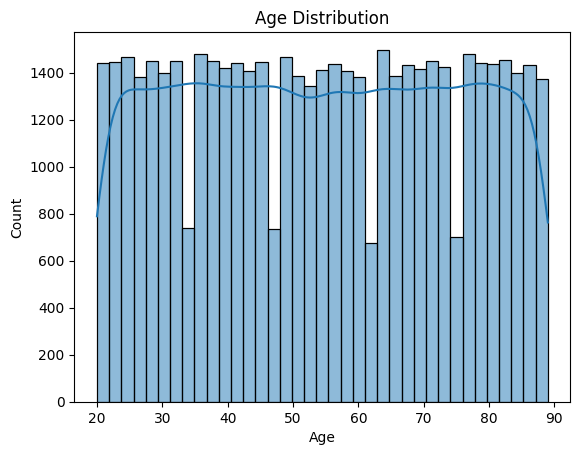

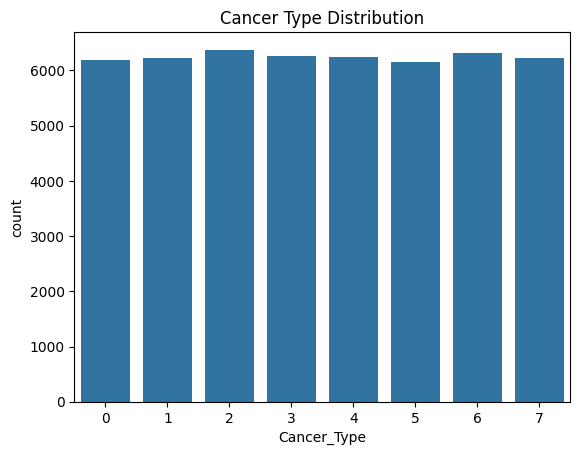

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of Age
sns.histplot(cancer_data['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

# Plot the distribution of Cancer Types
sns.countplot(x='Cancer_Type', data=cancer_data)
plt.title('Cancer Type Distribution')
plt.show()


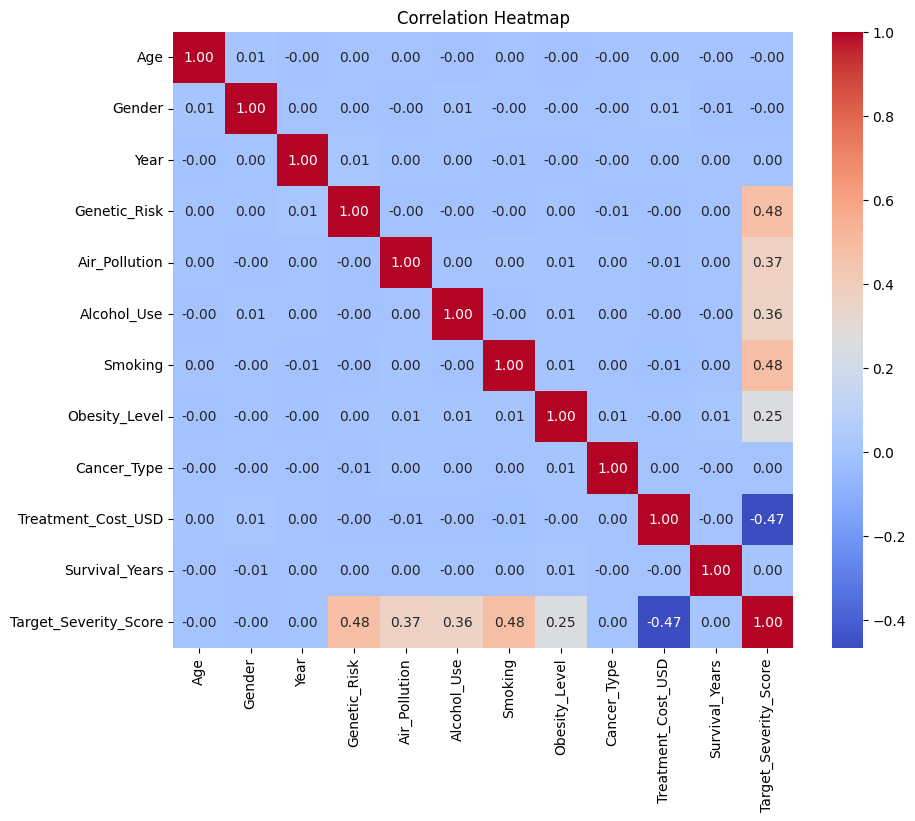

In [21]:
# Correlation heatmap for numerical features
numerical_cancer_data = cancer_data.select_dtypes(include=np.number)
corr = numerical_cancer_data.corr()  # Calculate correlation on numerical data only
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
X = cancer_data.drop(columns=['Target_Severity_Score'])
y = cancer_data['Target_Severity_Score']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])  # Encode training data
    X_test[col] = le.transform(X_test[col])

# Define models
models = {
    'Random Forest': RandomForestRegressor(),
    'Linear Regression': LinearRegression(),
    'XGBoost': xgb.XGBRegressor()
}

# Set hyperparameters for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(RandomForestRegressor(), param_distributions=param_dist_rf, n_iter=10, cv=5)
rf_random_search.fit(X_train, y_train)

# RandomizedSearchCV for XGBoost
xgb_random_search = RandomizedSearchCV(xgb.XGBRegressor(), param_distributions=param_dist_xgb, n_iter=10, cv=5)
xgb_random_search.fit(X_train, y_train)

# Print best parameters for each model
print("Best Parameters for Random Forest:", rf_random_search)
print("Best Parameters for XGBoost:", xgb_random_search)


Best Parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best Parameters for XGBoost: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [28]:
# Print best parameters for each model
print("Best Parameters for Random Forest:", rf_random_search)
print("Best Parameters for XGBoost:", xgb_random_search)


Best Parameters for Random Forest: RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(),
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]})
Best Parameters for XGBoost: RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
      

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

# Random Forest
rf_best_model = rf_random_search.best_estimator_
y_pred_rf = rf_best_model.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# XGBoost
xgb_best_model = xgb_random_search.best_estimator_
y_pred_xgb = xgb_best_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# Linear Regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Print Results
print(f"Random Forest - R²: {rf_r2:.4f}, RMSE: {rf_rmse:.4f}")
print(f"XGBoost - R²: {xgb_r2:.4f}, RMSE: {xgb_rmse:.4f}")
print(f"Linear Regression - R²: {lr_r2:.4f}, RMSE: {lr_rmse:.4f}")


Random Forest - R²: 0.9790, RMSE: 0.1726
XGBoost - R²: 0.9960, RMSE: 0.0753
Linear Regression - R²: 1.0000, RMSE: 0.0029


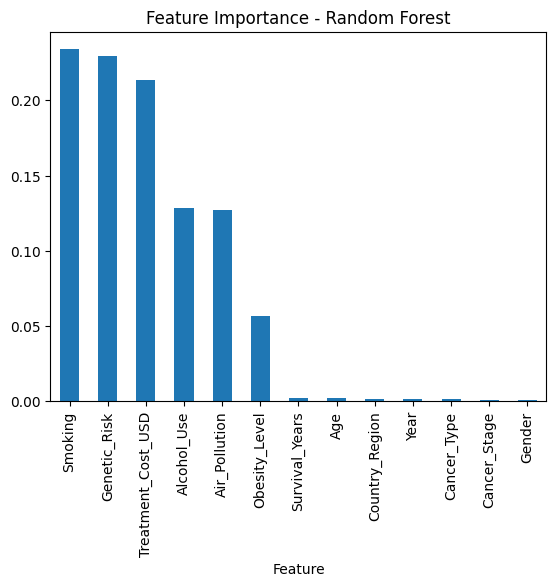

In [26]:
# Feature Importance - Random Forest
importances = rf_best_model.feature_importances_
features = X.columns

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the importance
feature_importance_df.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance - Random Forest')
plt.show()
